In [ ]:
import os
import numpy as np
import torch
import glob
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
import seaborn as sns
from tqdm import tqdm
from collections import OrderedDict

In [ ]:
NUM_CLASSES = 3
BATCH_SIZE = 64 
LEARNING_RATE = 0.0001
NUM_EPOCHS = 50
WARMUP_EPOCHS = 5
IMAGE_SIZE = 240
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
APPROACH1_WEIGHTS = '/kaggle/input/datasets/adman007/pretrained-models/phy_effnet_b0_best.pt'
ORIGINAL_B0_WEIGHTS = '/kaggle/input/datasets/adman007/pretrained-models/best_efficientNet_b0_classification_model.pt'
DATA_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset'

In [ ]:
class GravitationalLensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for file_path in glob.glob(os.path.join(class_dir, "*.npy")):
                self.samples.append((file_path, self.class_to_idx[class_name]))
    
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path)
        image = torch.from_numpy(image).float().repeat(3, 1, 1)
        if self.transform: image = self.transform(image)
        return image, label


class LensingLayer(nn.Module):
    def __init__(self, img_size=224):
        super(LensingLayer, self).__init__()
        self.img_size = img_size
        x = torch.linspace(-1, 1, img_size)
        y = torch.linspace(-1, 1, img_size)
        grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')
        self.register_buffer('grid', torch.stack((grid_y, grid_x), dim=-1).unsqueeze(0)) 

    def forward(self, x, alpha):
        batch_size = x.size(0)

        # Scale alpha down to prevent massive shifts that push the image off-canvas
        shift = (alpha * 0.05).view(batch_size, 1, 1, 2) 
    
        recon_grid = self.grid.expand(batch_size, -1, -1, -1) - shift
    
        # Use padding_mode='reflection' or 'border' instead of zeros (black/gray)
        source_recon = nn.functional.grid_sample(x, recon_grid, 
                                             align_corners=True, 
                                             padding_mode='border') 
        return source_recon

class PINNLensingModelV2(nn.Module):
    def __init__(self):
        super(PINNLensingModelV2, self).__init__()
        self.parameter_encoder = models.resnet34(weights=None)
        self.parameter_encoder.fc = nn.Linear(self.parameter_encoder.fc.in_features, 2)
        self.lensing_layer = LensingLayer(img_size=IMAGE_SIZE)
        self.classifier = models.efficientnet_b0(weights=None)
        self.classifier.classifier[1] = nn.Linear(self.classifier.classifier[1].in_features, NUM_CLASSES)

    def forward(self, x):
        alpha = self.parameter_encoder(x)
        source_recon = self.lensing_layer(x, alpha)
        return self.classifier(source_recon)


def initialize_hybrid_model(model, path_pinn, path_b0):
    model_state = model.state_dict()
    
    # 1. Loading ResNet-34 weights from Approach 1 (specific_test)
    if os.path.exists(path_pinn):
        print(f"Loading Physics weights from: {path_pinn}")
        pinn_state = torch.load(path_pinn, map_location=DEVICE)
        resnet_weights = {k.replace("_orig_mod.", ""): v for k, v in pinn_state.items() 
                          if 'parameter_encoder' in k}
        model_state.update(resnet_weights)
    
    # 2. Load efficientnet-B0 weights from Original Training (common_test)
    if os.path.exists(path_b0):
        print(f"Loading Classification weights from: {path_b0}")
        b0_state = torch.load(path_b0, map_location=DEVICE)
        b0_weights = {}
        
        for k, v in b0_state.items():
            
            clean_k = k.replace("_orig_mod.", "")
            
            if not clean_k.startswith('classifier.') and f'classifier.{clean_k}' in model_state:
                target_k = f'classifier.{clean_k}'
            else:
                target_k = clean_k
                
            # Final check: Does this key exist in our new model and do dimensions match?
            if target_k in model_state and v.size() == model_state[target_k].size():
                b0_weights[target_k] = v
        
        model_state.update(b0_weights)
        print(f"Successfully matched {len(b0_weights)} layers for the classifier.")

    model.load_state_dict(model_state, strict=False)
    print("Hybrid Initialization Complete.")



def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Val Acc')
    plt.plot(history['val_roc_auc'], label='Val ROC-AUC')
    plt.title('Metrics vs. Epoch')
    plt.legend()
    plt.show()

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_roc_curves(fpr, tpr, roc_auc, class_names):
    plt.figure(figsize=(8, 6))
    for i in range(NUM_CLASSES):
        plt.plot(fpr[i], tpr[i], label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.legend()
    plt.show()

def evaluate_and_plot(model, loader, class_names):
    model.eval()
    all_probs, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Final Eval"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_probs.append(probs.cpu().numpy()); all_labels.append(labels.numpy()); all_preds.append(preds.cpu().numpy())
    all_probs, all_labels, all_preds = np.concatenate(all_probs), np.concatenate(all_labels), np.concatenate(all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm, class_names)
    fpr, tpr, roc_auc_dict = {}, {}, {}
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        roc_auc_dict[i] = auc(fpr[i], tpr[i])
    plot_roc_curves(fpr, tpr, roc_auc_dict, class_names)


Loading Physics weights from: /kaggle/input/datasets/adman007/pretrained-models/phy_effnet_b0_best.pt
Loading Classification weights from: /kaggle/input/datasets/adman007/pretrained-models/best_efficientNet_b0_classification_model.pt
Successfully matched 358 layers for the classifier.
Hybrid Initialization Complete.


Epoch 1: 100%|██████████| 422/422 [01:14<00:00,  5.66it/s]


Val Acc: 0.9793 | AUC: 0.9980


Epoch 2: 100%|██████████| 422/422 [00:22<00:00, 19.08it/s]


Val Acc: 0.9630 | AUC: 0.9970


...

Epoch 49: 100%|██████████| 422/422 [00:33<00:00, 12.53it/s]


Val Acc: 0.9820 | AUC: 0.9986


Epoch 50: 100%|██████████| 422/422 [00:30<00:00, 13.68it/s]


Val Acc: 0.9853 | AUC: 0.9989


Final Eval: 100%|██████████| 47/47 [00:02<00:00, 17.03it/s]


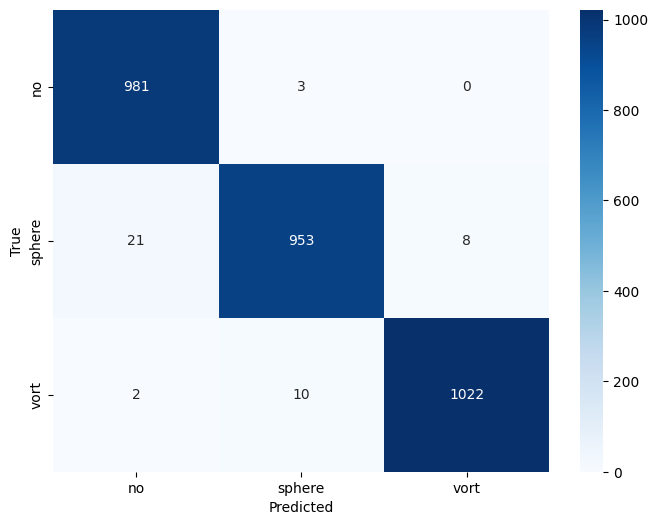

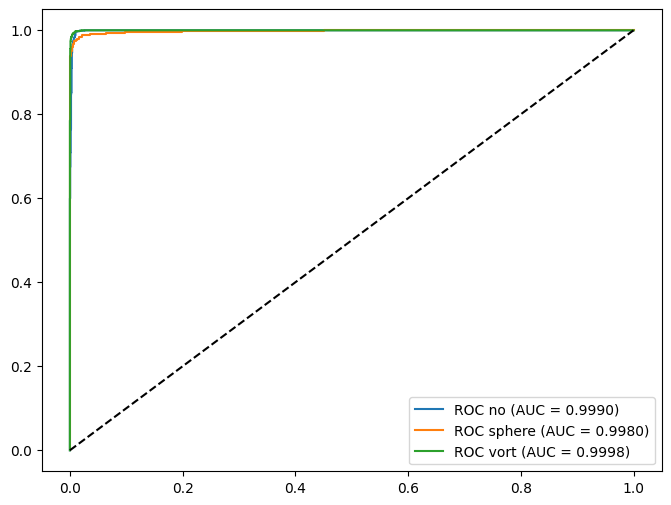

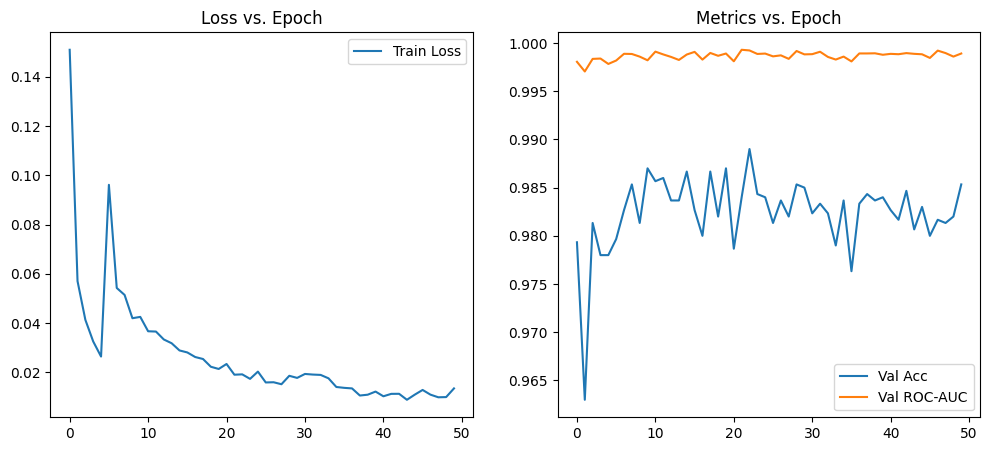

In [ ]:
transform = {"train": transforms.Compose([transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE), transforms.Normalize([0.5]*3, [0.5]*3)]),
             "val": transforms.Compose([transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE), transforms.Normalize([0.5]*3, [0.5]*3)])}

train_dir = os.path.join(DATA_DIR, 'train')
full_dataset = GravitationalLensingDataset(train_dir, transform=transform['train'])
train_ds, val_ds = random_split(full_dataset, [int(0.9*len(full_dataset)), len(full_dataset)-int(0.9*len(full_dataset))])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

model = PINNLensingModelV2().to(DEVICE)
initialize_hybrid_model(model, APPROACH1_WEIGHTS, ORIGINAL_B0_WEIGHTS)
model = torch.compile(model)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'val_acc': [], 'val_roc_auc': []}
best_auc = 0.0

for epoch in range(NUM_EPOCHS):
    if epoch < WARMUP_EPOCHS:
        for param in (model.module.parameter_encoder.parameters() if hasattr(model, 'module') else model.parameter_encoder.parameters()):
            param.requires_grad = False
        model.eval()
    else:
        for param in model.parameters(): param.requires_grad = True
        model.train()
    
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item()
    

    model.eval()
    v_probs, v_labels, correct, total = [], [], 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            out = model(inputs)
            v_probs.append(torch.softmax(out, 1).cpu().numpy()); v_labels.append(labels.cpu().numpy())
            _, pred = torch.max(out, 1); total += labels.size(0); correct += (pred == labels).sum().item()
    
    v_probs, v_labels = np.concatenate(v_probs), np.concatenate(v_labels)
    acc, auroc = correct/total, roc_auc_score(v_labels, v_probs, multi_class='ovr', average='macro')
    history['train_loss'].append(running_loss/len(train_loader)); history['val_acc'].append(acc); history['val_roc_auc'].append(auroc)
    print(f"Val Acc: {acc:.4f} | AUC: {auroc:.4f}")
    if auroc > best_auc:
        best_auc = auroc
        torch.save(model.state_dict(), 'pinn_approach2_hybrid_best.pt')

evaluate_and_plot(model, val_loader, full_dataset.classes)
plot_history(history)

In [ ]:

model.eval()
with torch.no_grad():
    sample_img, _ = next(iter(val_loader))
    alpha = model.parameter_encoder(sample_img.to(DEVICE))
    print(f"Sample Alpha Mean: {alpha.mean().item()}") 
    # If this isn't close to 0 at the start, the images are being warped off-screen.

Sample Alpha Mean: 0.29844823479652405


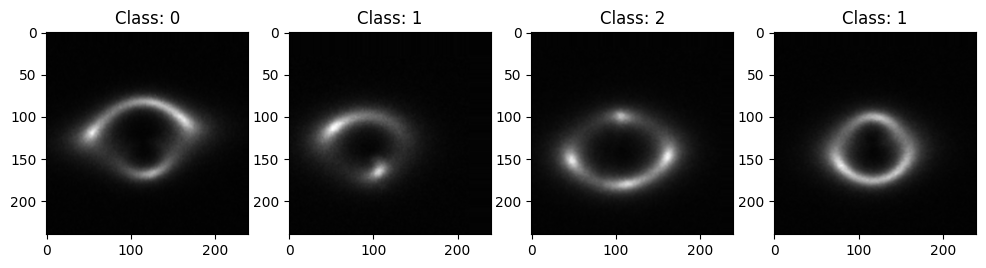

In [ ]:
import matplotlib.pyplot as plt

model.eval()
inputs, labels = next(iter(val_loader))
with torch.no_grad():
    # Simulating the forward pass up to the lensing layer
    alpha = model.parameter_encoder(inputs.to(DEVICE))
    recon_images = model.lensing_layer(inputs.to(DEVICE), alpha)

# Plot first 4 images
plt.figure(figsize=(12, 6))
for i in range(4):
    img = recon_images[i].cpu().numpy().transpose(1, 2, 0)
    img = (img * 0.5) + 0.5 # Un-normalize for display
    plt.subplot(1, 4, i+1)
    plt.imshow(np.clip(img, 0, 1))
    plt.title(f"Class: {labels[i].item()}")
plt.show()